# Cell 1: Install Environment (C++ and OpenMP)

In [1]:
!apt-get update > /dev/null
!apt-get install -y g++ > /dev/null
print("C++ and OpenMP ready")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
C++ and OpenMP ready


# Cell 2: Generate Synthetic Datasets (5000, 7500, 10000 points)

In [2]:
import pandas as pd
import random
import numpy as np

def create_dataset(size, filename=None):
    """Generate 2D random data in [0,100]x[0,100]."""
    data = [[random.uniform(0,100), random.uniform(0,100)] for _ in range(size)]
    df = pd.DataFrame(data, columns=["x","y"])
    if filename is None:
        filename = f"dataset_{size}.csv"
    df.to_csv(filename, index=False)
    print(f"Created {filename} with {size} points")
    return filename

sizes = [5000, 7500, 10000]
for n in sizes:
    create_dataset(n)

Created dataset_5000.csv with 5000 points
Created dataset_7500.csv with 7500 points
Created dataset_10000.csv with 10000 points


# Cell 3: Sequential K‑Means Implementation (with K‑means++ and convergence)

In [3]:
%%writefile sequential_kmeans.cpp
/**
 * Sequential K-Means Clustering
 * - K-means++ initialization
 * - Convergence based on centroid movement
 * - Saves final centroids to file for verification
 */
#include <iostream>
#include <fstream>
#include <vector>
#include <cmath>
#include <limits>
#include <chrono>
#include <random>
#include <omp.h>

using namespace std;

struct Point {
    double x, y;
};

double dist(const Point& a, const Point& b) {
    double dx = a.x - b.x;
    double dy = a.y - b.y;
    return sqrt(dx*dx + dy*dy);
}

// K-means++ initialization
vector<Point> kmeansPlusPlus(const vector<Point>& data, int K, mt19937& rng) {
    int N = data.size();
    vector<Point> centroids;
    uniform_int_distribution<int> distIdx(0, N-1);
    // Choose first centroid randomly
    centroids.push_back(data[distIdx(rng)]);

    vector<double> minDist(N, 0.0);
    for (int c = 1; c < K; ++c) {
        double sum = 0.0;
        for (int i = 0; i < N; ++i) {
            double d = dist(data[i], centroids[0]);
            for (int j = 1; j < c; ++j) {
                d = min(d, dist(data[i], centroids[j]));
            }
            minDist[i] = d;
            sum += d;
        }
        uniform_real_distribution<double> distProb(0.0, sum);
        double r = distProb(rng);
        double cum = 0.0;
        int selected = N-1;
        for (int i = 0; i < N; ++i) {
            cum += minDist[i];
            if (cum >= r) { selected = i; break; }
        }
        centroids.push_back(data[selected]);
    }
    return centroids;
}

// Load data from CSV
vector<Point> loadData(const string& filename) {
    vector<Point> data;
    ifstream file(filename);
    if (!file.is_open()) {
        cerr << "Error: Could not open " << filename << endl;
        exit(1);
    }
    string line;
    getline(file, line); // skip header
    while (getline(file, line)) {
        size_t pos = line.find(',');
        if (pos == string::npos) continue;
        double x = stod(line.substr(0, pos));
        double y = stod(line.substr(pos+1));
        data.push_back({x, y});
    }
    return data;
}

// Compute within-cluster sum of squares
double computeWCSS(const vector<Point>& data, const vector<int>& labels,
                   const vector<Point>& centroids) {
    double total = 0.0;
    for (size_t i = 0; i < data.size(); ++i) {
        double d = dist(data[i], centroids[labels[i]]);
        total += d*d;
    }
    return total;
}

// Save centroids to file for verification
void saveCentroids(const vector<Point>& centroids, const string& filename) {
    ofstream out(filename);
    for (const auto& c : centroids)
        out << c.x << "," << c.y << "\n";
    out.close();
}

int main(int argc, char* argv[]) {
    if (argc < 4) {
        cerr << "Usage: ./seq dataset.csv K maxIter [tol]\n";
        return 1;
    }
    string filename = argv[1];
    int K = stoi(argv[2]);
    int maxIter = stoi(argv[3]);
    double tol = (argc >= 5) ? stod(argv[4]) : 1e-4;

    vector<Point> data = loadData(filename);
    int N = data.size();

    // Seed for reproducibility
    mt19937 rng(12345);

    // K-means++ initialization
    vector<Point> centroids = kmeansPlusPlus(data, K, rng);
    vector<int> labels(N, 0);

    double start_time = omp_get_wtime();

    bool converged = false;
    int iter = 0;
    for (iter = 0; iter < maxIter && !converged; ++iter) {
        // Assignment
        for (int i = 0; i < N; ++i) {
            double best = numeric_limits<double>::max();
            int bestC = 0;
            for (int c = 0; c < K; ++c) {
                double d = dist(data[i], centroids[c]);
                if (d < best) { best = d; bestC = c; }
            }
            labels[i] = bestC;
        }

        // Update
        vector<Point> newCentroids(K, {0.0, 0.0});
        vector<int> counts(K, 0);
        for (int i = 0; i < N; ++i) {
            int c = labels[i];
            newCentroids[c].x += data[i].x;
            newCentroids[c].y += data[i].y;
            counts[c]++;
        }
        // Check for empty clusters and reinitialize (if any count==0)
        double maxMove = 0.0;
        for (int c = 0; c < K; ++c) {
            if (counts[c] == 0) {
                // reinitialize with a random point (simple)
                int idx = rand() % N;
                newCentroids[c] = data[idx];
                counts[c] = 1;
            } else {
                newCentroids[c].x /= counts[c];
                newCentroids[c].y /= counts[c];
            }
            maxMove = max(maxMove, dist(centroids[c], newCentroids[c]));
        }
        centroids = newCentroids;
        if (maxMove < tol) converged = true;
    }

    double end_time = omp_get_wtime();
    double time_ms = (end_time - start_time) * 1000.0;

    double wcss = computeWCSS(data, labels, centroids);

    // Output results (machine-readable for the Python driver)
    cout << "Time:" << time_ms << "\n";
    cout << "WCSS:" << wcss << "\n";
    cout << "Iterations:" << iter << "\n";
    cout << "Converged:" << (converged ? "1" : "0") << "\n";

    // Save centroids for verification
    saveCentroids(centroids, "centroids_seq.csv");

    return 0;
}

Writing sequential_kmeans.cpp


# Cell 4: Parallel K‑Means Implementation (OpenMP with atomic updates)

In [4]:
%%writefile parallel_kmeans.cpp
/**
 * Parallel K-Means Clustering with OpenMP
 * - K-means++ initialization (identical to sequential)
 * - Parallel assignment with dynamic scheduling
 * - Parallel update using atomic operations (or private copies)
 * - Convergence and correctness check (centroids saved)
 */
#include <iostream>
#include <fstream>
#include <vector>
#include <cmath>
#include <limits>
#include <random>
#include <omp.h>

using namespace std;

struct Point {
    double x, y;
};

double dist(const Point& a, const Point& b) {
    double dx = a.x - b.x;
    double dy = a.y - b.y;
    return sqrt(dx*dx + dy*dy);
}

// K-means++ initialization (same as sequential)
vector<Point> kmeansPlusPlus(const vector<Point>& data, int K, mt19937& rng) {
    int N = data.size();
    vector<Point> centroids;
    uniform_int_distribution<int> distIdx(0, N-1);
    centroids.push_back(data[distIdx(rng)]);
    vector<double> minDist(N, 0.0);
    for (int c = 1; c < K; ++c) {
        double sum = 0.0;
        for (int i = 0; i < N; ++i) {
            double d = dist(data[i], centroids[0]);
            for (int j = 1; j < c; ++j)
                d = min(d, dist(data[i], centroids[j]));
            minDist[i] = d;
            sum += d;
        }
        uniform_real_distribution<double> distProb(0.0, sum);
        double r = distProb(rng);
        double cum = 0.0;
        int selected = N-1;
        for (int i = 0; i < N; ++i) {
            cum += minDist[i];
            if (cum >= r) { selected = i; break; }
        }
        centroids.push_back(data[selected]);
    }
    return centroids;
}

vector<Point> loadData(const string& filename) {
    vector<Point> data;
    ifstream file(filename);
    if (!file.is_open()) {
        cerr << "Error: Could not open " << filename << endl;
        exit(1);
    }
    string line;
    getline(file, line);
    while (getline(file, line)) {
        size_t pos = line.find(',');
        if (pos == string::npos) continue;
        double x = stod(line.substr(0, pos));
        double y = stod(line.substr(pos+1));
        data.push_back({x, y});
    }
    return data;
}

double computeWCSS(const vector<Point>& data, const vector<int>& labels,
                   const vector<Point>& centroids) {
    double total = 0.0;
    for (size_t i = 0; i < data.size(); ++i) {
        double d = dist(data[i], centroids[labels[i]]);
        total += d*d;
    }
    return total;
}

void saveCentroids(const vector<Point>& centroids, const string& filename) {
    ofstream out(filename);
    for (const auto& c : centroids)
        out << c.x << "," << c.y << "\n";
    out.close();
}

int main(int argc, char* argv[]) {
    if (argc < 4) {
        cerr << "Usage: ./par dataset.csv K maxIter [tol]\n";
        return 1;
    }
    string filename = argv[1];
    int K = stoi(argv[2]);
    int maxIter = stoi(argv[3]);
    double tol = (argc >= 5) ? stod(argv[4]) : 1e-4;

    vector<Point> data = loadData(filename);
    int N = data.size();

    mt19937 rng(12345);
    vector<Point> centroids = kmeansPlusPlus(data, K, rng);
    vector<int> labels(N, 0);

    double start_time = omp_get_wtime();

    bool converged = false;
    int iter = 0;
    for (iter = 0; iter < maxIter && !converged; ++iter) {
        // ----- Assignment (parallel) -----
        #pragma omp parallel for schedule(dynamic, 64)
        for (int i = 0; i < N; ++i) {
            double best = numeric_limits<double>::max();
            int bestC = 0;
            for (int c = 0; c < K; ++c) {
                double d = dist(data[i], centroids[c]);
                if (d < best) { best = d; bestC = c; }
            }
            labels[i] = bestC;
        }

        // ----- Update (parallel with atomic) -----
        vector<Point> newCentroids(K, {0.0, 0.0});
        vector<int> counts(K, 0);

        #pragma omp parallel for
        for (int i = 0; i < N; ++i) {
            int c = labels[i];
            #pragma omp atomic
            newCentroids[c].x += data[i].x;
            #pragma omp atomic
            newCentroids[c].y += data[i].y;
            #pragma omp atomic
            counts[c]++;
        }

        // Handle empty clusters and compute max move
        double maxMove = 0.0;
        for (int c = 0; c < K; ++c) {
            if (counts[c] == 0) {
                // reinitialize with a random point (same as sequential)
                int idx = rand() % N;
                newCentroids[c] = data[idx];
                counts[c] = 1;
            } else {
                newCentroids[c].x /= counts[c];
                newCentroids[c].y /= counts[c];
            }
            maxMove = max(maxMove, dist(centroids[c], newCentroids[c]));
        }
        centroids = newCentroids;
        if (maxMove < tol) converged = true;
    }

    double end_time = omp_get_wtime();
    double time_ms = (end_time - start_time) * 1000.0;

    double wcss = computeWCSS(data, labels, centroids);

    cout << "Time:" << time_ms << "\n";
    cout << "WCSS:" << wcss << "\n";
    cout << "Iterations:" << iter << "\n";
    cout << "Converged:" << (converged ? "1" : "0") << "\n";

    // Save centroids for verification (parallel)
    saveCentroids(centroids, "centroids_par.csv");

    return 0;
}

Writing parallel_kmeans.cpp


# Cell 5: Compile Both Programs

In [5]:
!g++ -O2 -fopenmp sequential_kmeans.cpp -o seq
!g++ -O2 -fopenmp parallel_kmeans.cpp -o par
print("Compilation successful.")

Compilation successful.


# Cell 6: Run Experiments and Collect Data

In [6]:
import subprocess
import pandas as pd
import numpy as np
import time
import os

# Parameters
sizes = [5000, 7500, 10000]
K_values = [3, 5]                  # we can test different K
threads = [1, 2, 4, 8]
repetitions = 3                    # number of runs per configuration
maxIter = 100
tol = 1e-4

results = []

# Pre-generate datasets (if not already)
for n in sizes:
    if not os.path.exists(f"dataset_{n}.csv"):
        create_dataset(n)

for n in sizes:
    for K in K_values:
        dataset = f"dataset_{n}.csv"
        # --- Sequential run (once, because it's deterministic) ---
        cmd_seq = f"./seq {dataset} {K} {maxIter} {tol}"
        out_seq = subprocess.check_output(cmd_seq, shell=True, text=True)
        # parse output
        lines = out_seq.strip().split('\n')
        time_seq = float(lines[0].split(':')[1])
        wcss_seq = float(lines[1].split(':')[1])
        iters_seq = int(lines[2].split(':')[1])
        conv_seq = int(lines[3].split(':')[1])
        # store sequential baseline
        results.append({
            'Type': 'Sequential',
            'Size': n,
            'K': K,
            'Threads': 1,
            'Run': 0,
            'Time(ms)': time_seq,
            'WCSS': wcss_seq,
            'Iterations': iters_seq,
            'Converged': conv_seq
        })

        # --- Parallel runs with different thread counts ---
        for t in threads:
            for run in range(1, repetitions+1):
                cmd_par = f"OMP_NUM_THREADS={t} ./par {dataset} {K} {maxIter} {tol}"
                out_par = subprocess.check_output(cmd_par, shell=True, text=True)
                lines_par = out_par.strip().split('\n')
                time_par = float(lines_par[0].split(':')[1])
                wcss_par = float(lines_par[1].split(':')[1])
                iters_par = int(lines_par[2].split(':')[1])
                conv_par = int(lines_par[3].split(':')[1])
                # Also verify centroids match sequential (by comparing WCSS and maybe file content)
                # We'll store WCSS difference for sanity
                results.append({
                    'Type': 'Parallel',
                    'Size': n,
                    'K': K,
                    'Threads': t,
                    'Run': run,
                    'Time(ms)': time_par,
                    'WCSS': wcss_par,
                    'Iterations': iters_par,
                    'Converged': conv_par
                })
        # Clean up centroids files (optional)
        # os.remove("centroids_seq.csv")
        # os.remove("centroids_par.csv")

# Convert to DataFrame
df = pd.DataFrame(results)
print("Data collection complete.")
df.head()

Data collection complete.


,Type,Size,K,Threads,Run,Time(ms),WCSS,Iterations,Converged
0,Sequential,5000,3,1,0,2.63695,3283790.0,42,1
1,Parallel,5000,3,1,1,8.72003,3283790.0,42,1
2,Parallel,5000,3,1,2,9.81454,3283790.0,42,1
3,Parallel,5000,3,1,3,9.25328,3283790.0,42,1
4,Parallel,5000,3,2,1,9.88740,3283790.0,42,1


# Cell 7: Process Results – Speedup, Efficiency, and Verification
# For each (Size, K, Threads) compute average time and speedup relative to sequential
# First, compute average over runs for parallel

In [7]:
df_par = df[df.Type == 'Parallel'].groupby(['Size','K','Threads']).agg({
    'Time(ms)': ['mean', 'std'],
    'WCSS': 'mean',
    'Iterations': 'mean',
    'Converged': 'mean'
}).reset_index()
df_par.columns = ['Size','K','Threads','Time_mean','Time_std','WCSS_mean','Iterations_mean','Converged_mean']

# Get sequential baseline (only one run per Size,K)
df_seq = df[df.Type == 'Sequential'].copy()
df_seq = df_seq[['Size','K','Time(ms)','WCSS']].rename(columns={'Time(ms)':'SeqTime','WCSS':'SeqWCSS'})

# Merge
df_perf = pd.merge(df_par, df_seq, on=['Size','K'])
df_perf['Speedup'] = df_perf['SeqTime'] / df_perf['Time_mean']
df_perf['Efficiency'] = (df_perf['Speedup'] / df_perf['Threads']) * 100
df_perf['WCSS_diff'] = abs(df_perf['WCSS_mean'] - df_perf['SeqWCSS']) / df_perf['SeqWCSS'] * 100  # relative diff

print("Performance summary (averaged over runs):")
df_perf[['Size','K','Threads','Time_mean','Time_std','Speedup','Efficiency','WCSS_diff']]

Performance summary (averaged over runs):


,Size,K,Threads,Time_mean,Time_std,Speedup,Efficiency,WCSS_diff
0,5000,3,1,9.262617,0.547315,0.284687,28.468737,0.0
1,5000,3,2,9.700113,0.162196,0.271847,13.592367,0.0
2,5000,3,4,12.637800,1.025445,0.208656,5.216394,0.0
3,5000,3,8,15.212300,0.228614,0.173343,2.166791,0.0
4,5000,5,1,4.165790,0.107171,0.359932,35.993173,0.0
5,5000,5,2,4.131233,0.004282,0.362942,18.147123,0.0
6,5000,5,4,4.878523,0.022567,0.307347,7.683678,0.0
7,5000,5,8,5.826193,0.025454,0.257355,3.216938,0.0
8,7500,3,1,6.565000,0.027672,0.290783,29.078294,0.0
9,7500,3,2,6.974540,0.120960,0.273708,13.685419,0.0


# Cell 8: Generate Graphs (Execution Time, Speedup, Scalability)

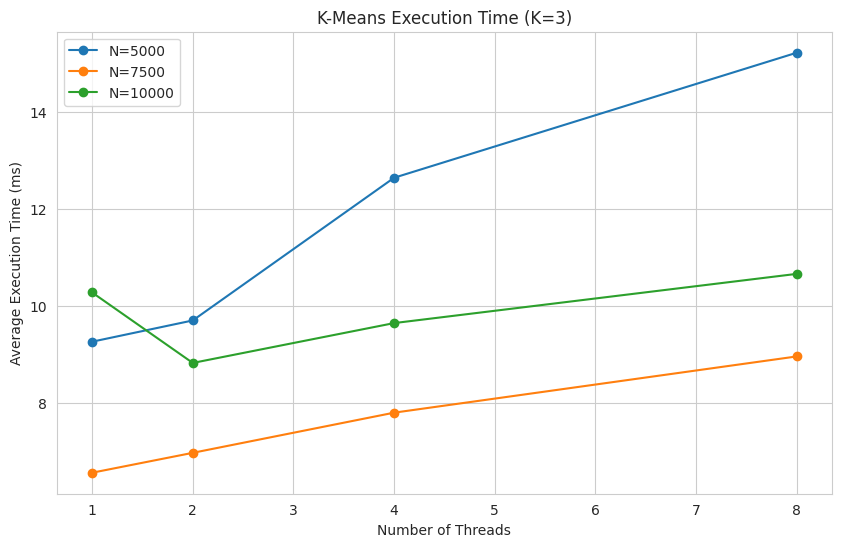

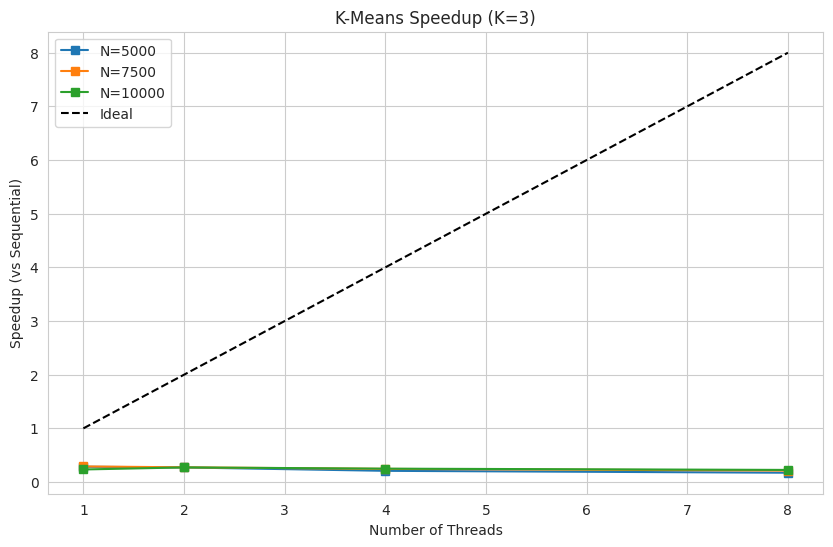

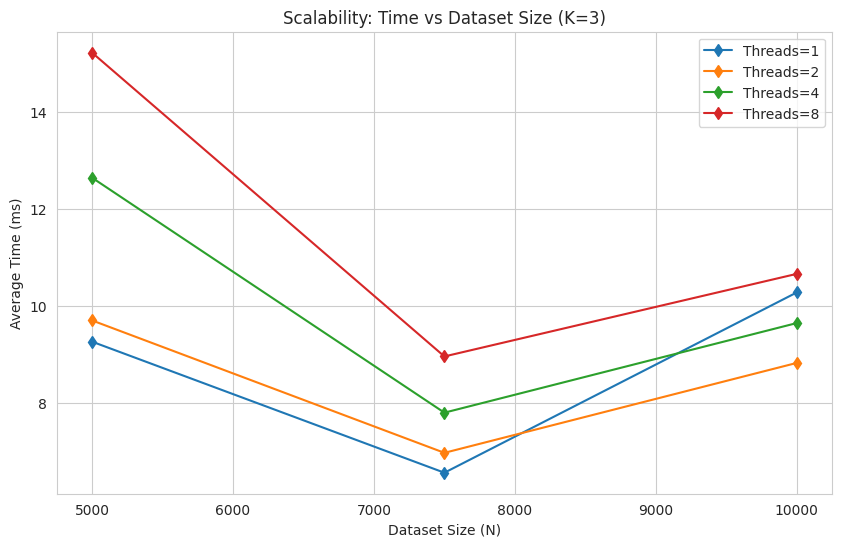

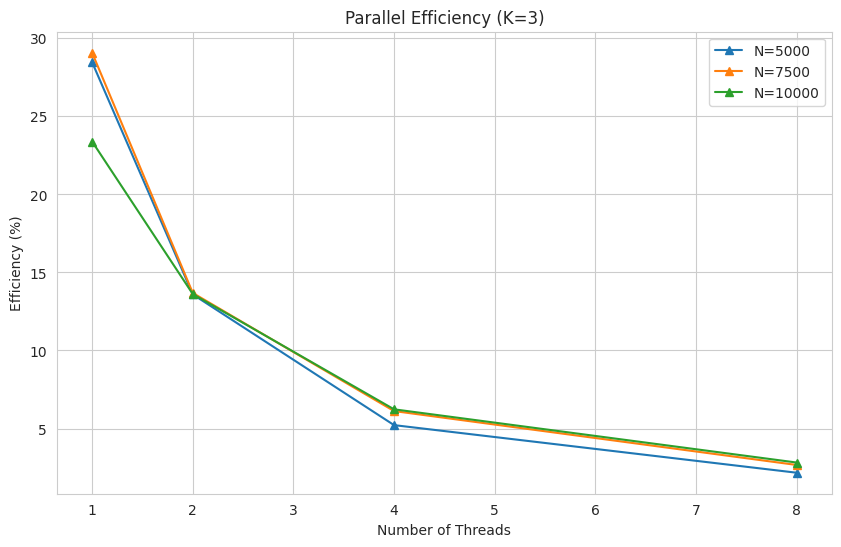

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# For clarity, we pick one K (e.g., K=3) and plot for each dataset size.
K_fixed = 3
df_plot = df_perf[df_perf.K == K_fixed]

# --- Execution Time vs Threads ---
plt.figure(figsize=(10,6))
for n in sizes:
    sub = df_plot[df_plot.Size == n]
    plt.plot(sub['Threads'], sub['Time_mean'], marker='o', label=f'N={n}')
plt.xlabel('Number of Threads')
plt.ylabel('Average Execution Time (ms)')
plt.title(f'K-Means Execution Time (K={K_fixed})')
plt.legend()
plt.grid(True)
plt.savefig('execution_time.png', dpi=300)
plt.show()

# --- Speedup vs Threads ---
plt.figure(figsize=(10,6))
for n in sizes:
    sub = df_plot[df_plot.Size == n]
    plt.plot(sub['Threads'], sub['Speedup'], marker='s', label=f'N={n}')
plt.plot([1, max(threads)], [1, max(threads)], 'k--', label='Ideal')
plt.xlabel('Number of Threads')
plt.ylabel('Speedup (vs Sequential)')
plt.title(f'K-Means Speedup (K={K_fixed})')
plt.legend()
plt.grid(True)
plt.savefig('speedup.png', dpi=300)
plt.show()

# --- Scalability: Time vs Dataset Size for different thread counts ---
plt.figure(figsize=(10,6))
for t in threads:
    sub = df_plot[df_plot.Threads == t]
    # sort by size
    sub = sub.sort_values('Size')
    plt.plot(sub['Size'], sub['Time_mean'], marker='d', label=f'Threads={t}')
plt.xlabel('Dataset Size (N)')
plt.ylabel('Average Time (ms)')
plt.title(f'Scalability: Time vs Dataset Size (K={K_fixed})')
plt.legend()
plt.grid(True)
plt.savefig('scalability.png', dpi=300)
plt.show()

# --- Efficiency vs Threads ---
plt.figure(figsize=(10,6))
for n in sizes:
    sub = df_plot[df_plot.Size == n]
    plt.plot(sub['Threads'], sub['Efficiency'], marker='^', label=f'N={n}')
plt.xlabel('Number of Threads')
plt.ylabel('Efficiency (%)')
plt.title(f'Parallel Efficiency (K={K_fixed})')
plt.legend()
plt.grid(True)
plt.savefig('efficiency.png', dpi=300)
plt.show()

# Cell 9: Verify Correctness (WCSS difference)
# Check that WCSS differences are small (should be < 0.1%)

In [9]:
print("WCSS relative difference (parallel vs sequential):")
print(df_perf[['Size','K','Threads','WCSS_diff']].sort_values(['Size','K','Threads']))

WCSS relative difference (parallel vs sequential):
     Size  K  Threads  WCSS_diff
0    5000  3        1        0.0
1    5000  3        2        0.0
2    5000  3        4        0.0
3    5000  3        8        0.0
4    5000  5        1        0.0
5    5000  5        2        0.0
6    5000  5        4        0.0
7    5000  5        8        0.0
8    7500  3        1        0.0
9    7500  3        2        0.0
10   7500  3        4        0.0
11   7500  3        8        0.0
12   7500  5        1        0.0
13   7500  5        2        0.0
14   7500  5        4        0.0
15   7500  5        8        0.0
16  10000  3        1        0.0
17  10000  3        2        0.0
18  10000  3        4        0.0
19  10000  3        8        0.0
20  10000  5        1        0.0
21  10000  5        2        0.0
22  10000  5        4        0.0
23  10000  5        8        0.0


# Cell 10: Export Summary Table to CSV for Report
# We'll produce a clean table with speedup and efficiency for K=3 and N=10000

In [10]:
summary = df_perf[(df_perf.K==3) & (df_perf.Size==10000)]
summary = summary[['Threads','Time_mean','Time_std','Speedup','Efficiency']]
summary.to_csv('summary_results.csv', index=False)
print("Summary results saved to summary_results.csv")
print(summary)

Summary results saved to summary_results.csv
    Threads  Time_mean  Time_std   Speedup  Efficiency
16        1  10.275660  1.351319  0.233879   23.387889
17        2   8.825303  0.266702  0.272315   13.615736
18        4   9.645780  0.093026  0.249151    6.228786
19        8  10.658900  0.092681  0.225470    2.818372


# Cell 11: Additional Analysis – Amdahl's Law (optional)
# We can estimate parallel fraction from speedup using Amdahl's law.
# For N=10000, K=3, we compute the serial fraction from speedup at 8 threads.
# This is for the report discussion.

Estimated parallel fraction (Amdahl) = -4.509
Estimated serial fraction = 5.509


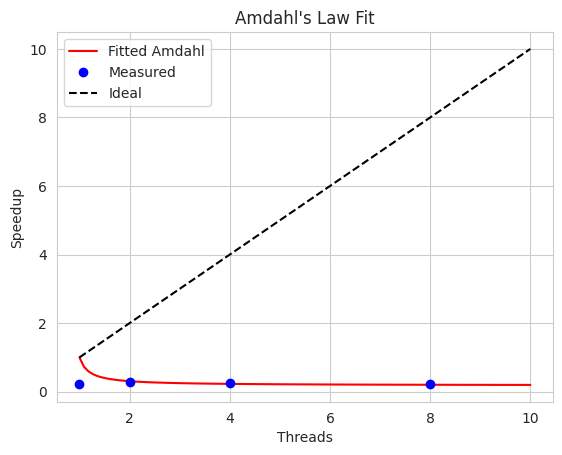

In [11]:
import numpy as np
from scipy.optimize import curve_fit

def amdahl(p, f):
    # p: number of processors, f: parallel fraction (0-1)
    return 1 / ( (1-f) + f/p )

# Use data for N=10000, K=3
sub = df_perf[(df_perf.K==3) & (df_perf.Size==10000)]
p = sub['Threads'].values
s = sub['Speedup'].values

# Fit to get f (parallel fraction)
# We'll use curve_fit to estimate f
popt, pcov = curve_fit(amdahl, p, s, p0=[0.9])
f_est = popt[0]
print(f"Estimated parallel fraction (Amdahl) = {f_est:.3f}")
print(f"Estimated serial fraction = {1-f_est:.3f}")

# Plot fitted curve
plt.figure()
p_plot = np.linspace(1, 10, 100)
plt.plot(p_plot, amdahl(p_plot, f_est), 'r-', label='Fitted Amdahl')
plt.plot(p, s, 'bo', label='Measured')
plt.plot(p_plot, p_plot, 'k--', label='Ideal')
plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Amdahl\'s Law Fit')
plt.legend()
plt.grid(True)
plt.savefig('amdahl_fit.png', dpi=300)
plt.show()